**Tantangan dalam Manajemen Rambu Lalu Lintas**

Rambu lalu lintas menyampaikan informasi penting kepada pengemudi. Namun, efektivitasnya dapat terganggu oleh berbagai faktor, seperti keterlihatan di bawah kondisi pencahayaan yang berbeda atau adanya hambatan.

**Pelatihan Model Deteksi Rambu Lalu Lintas**

Untuk mengatasi tantangan ini dan meningkatkan kemampuan deteksi rambu berhenti dan lampu lalu lintas, teknologi canggih seperti pembelajaran mendalam dan penglihatan komputer telah mendapatkan perhatian yang signifikan. Dalam proyek ini, Anda akan melatih model deteksi objek pada 6 gambar rambu berhenti dan 6 gambar lampu lalu lintas, yang diambil dari berbagai sudut dan kondisi pencahayaan. Pelatihan ini mengajarkan model untuk mengklasifikasikan dan menentukan lokasi rambu-rambu ini dalam gambar, meningkatkan ketangguhan dan keandalannya untuk aplikasi dunia nyata.


Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).


(-0.5, 223.5, 223.5, -0.5)

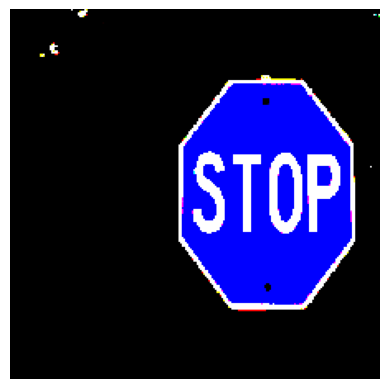

In [1]:
# Import required libraries
import numpy as np
import matplotlib.pyplot as plt
from tensorflow import keras

# Load preprocessed images and labels
image, labels = np.load('batch.npy',allow_pickle=True).tolist()

# hyperparameters
input_size = image.shape[1] # dimension of input image
num_classes = labels['classifier_head'].shape[1] # number of classes
DROPOUT_FACTOR = 0.2 # dropout probability

# visualize one example preprocessed image
plt.imshow(image[2])
plt.axis("off")

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).


(-0.5, 223.5, 223.5, -0.5)

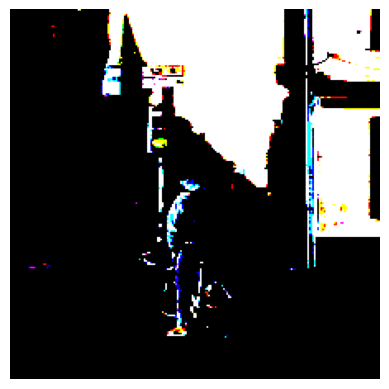

In [8]:
# visualize one example preprocessed image
plt.imshow(image[11])
plt.axis("off")

In [9]:
# Import required libraries
import numpy as np
import matplotlib.pyplot as plt
from tensorflow import keras

model = keras.Sequential()

# Feature extractor: This part of the model extracts features from the input images
# Convolutional layer with 16 filters, each filter with a size of 3x3, using ReLU activation function
# Input shape is the size of the input image: (input_size, input_size, 3) - 3 channels for RGB images
model.add(keras.layers.Conv2D(16, kernel_size=3, activation='relu', input_shape=(input_size, input_size, 3)))

model.add(keras.layers.AveragePooling2D(2, 2))

model.add(keras.layers.Conv2D(32, kernel_size=3, activation='relu'))

model.add(keras.layers.AveragePooling2D(2, 2))

model.add(keras.layers.Conv2D(64, kernel_size=3, activation='relu'))

model.add(keras.layers.Dropout(DROPOUT_FACTOR))

model.add(keras.layers.AveragePooling2D(2, 2))

# Model adaptor: This part of the model adapts the extracted features for classification
# Flatten layer to convert the 3D feature maps into a 1D feature vector
model.add(keras.layers.Flatten())
# Dense (fully connected) layer with 64 neurons and ReLU activation
model.add(keras.layers.Dense(64, activation='relu'))

# Classifier head: This part of the model performs the actual classification
# Dense layer with 64 neurons and ReLU activation
model.add(keras.layers.Dense(64, activation='relu'))
# Output layer with 'num_classes' neurons and softmax activation, representing class probabilities
model.add(keras.layers.Dense(num_classes, activation='softmax', name='classifier_head'))

# Compile the model: Define optimizer, loss function, and evaluation metrics
model.compile(optimizer='adam',
              loss='categorical_crossentropy',
              metrics=['accuracy'])

history = model.fit(image, labels['classifier_head'], epochs=20)

# Print the training accuracy
accuracy = history.history['accuracy'][-1]
print(f"Training accuracy: {accuracy}")


Epoch 1/20
1/1 [==============================] - 1s 1s/step - loss: 14.8292 - accuracy: 0.5000
Epoch 2/20
1/1 [==============================] - 0s 172ms/step - loss: 78.7506 - accuracy: 0.5000
Epoch 3/20
1/1 [==============================] - 0s 167ms/step - loss: 2.5226 - accuracy: 0.5833
Epoch 4/20
1/1 [==============================] - 0s 169ms/step - loss: 8.6062 - accuracy: 0.5000
Epoch 5/20
1/1 [==============================] - 0s 164ms/step - loss: 1.8561 - accuracy: 0.7500
Epoch 6/20
1/1 [==============================] - 0s 163ms/step - loss: 1.6972 - accuracy: 0.7500
Epoch 7/20
1/1 [==============================] - 0s 261ms/step - loss: 0.7693 - accuracy: 0.8333
Epoch 8/20
1/1 [==============================] - 0s 178ms/step - loss: 0.0227 - accuracy: 1.0000
Epoch 9/20
1/1 [==============================] - 0s 172ms/step - loss: 0.0049 - accuracy: 1.0000
Epoch 10/20
1/1 [==============================] - 0s 170ms/step - loss: 0.0046 - accuracy: 1.0000
Epoch 11/20
1/1 [===